In [1]:
# Core libraries for data handling
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# ML utilities
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [2]:
# Load global weather dataset
df = pd.read_csv("../data/GlobalWeatherRepository.csv")  

In [3]:
# Preview dataset structure
df.head()


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [4]:
# Check data types and missing values
df.info()

# Statistical summary of numerical features
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 144042 entries, 0 to 144041
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       144042 non-null  str    
 1   location_name                 144042 non-null  str    
 2   latitude                      144042 non-null  float64
 3   longitude                     144042 non-null  float64
 4   timezone                      144042 non-null  str    
 5   last_updated_epoch            144042 non-null  int64  
 6   last_updated                  144042 non-null  str    
 7   temperature_celsius           144042 non-null  float64
 8   temperature_fahrenheit        144042 non-null  float64
 9   condition_text                144042 non-null  str    
 10  wind_mph                      144042 non-null  float64
 11  wind_kph                      144042 non-null  float64
 12  wind_degree                   144042 non-null  int64  


,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,144042.000000,144042.000000,1.440420e+05,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,...,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000
mean,19.220147,21.927988,1.747906e+09,21.251517,70.254505,7.978145,12.843317,169.014732,1014.052672,29.944383,...,18.173365,448.354500,57.480166,14.788031,10.092657,23.809471,47.695592,1.685189,2.573000,49.708731
std,24.411327,65.781188,1.850449e+07,9.612287,17.302011,7.103576,11.428770,103.680984,10.156986,0.299883,...,13.657232,741.426453,30.372750,23.275684,34.669843,36.197597,147.177007,0.933054,2.420859,35.014189
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.960000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,4.050300,-6.836100,1.731920e+09,15.700000,60.200000,3.800000,6.100000,80.000000,1010.000000,29.830000,...,10.200000,194.250000,38.000000,1.800000,1.110000,7.030000,9.805000,1.000000,1.000000,15.000000
50%,17.250000,23.236100,1.747904e+09,23.700000,74.600000,6.700000,10.800000,161.000000,1013.000000,29.930000,...,15.300000,286.750000,55.000000,5.735000,2.405000,13.875000,19.600000,1.000000,2.000000,50.000000
75%,40.400000,49.882200,1.763882e+09,27.900000,82.300000,11.000000,17.600000,256.000000,1018.000000,30.060000,...,24.100000,449.550000,73.000000,17.020000,8.050000,27.350000,40.804000,2.000000,3.000000,84.000000
max,64.150000,179.220000,1.779949e+09,79.300000,174.700000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


In [5]:
# Check missing values in dataset
df.isnull().sum()


country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Ni

In [6]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [7]:
# Random sample inspection for sanity check
df.sample(5)

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
110610,Iran,Chi Chi Khvar,36.2625,46.5900,Asia/Tehran,1765005300,2025-12-06 10:45,9.4,49.0,Sunny,...,23.350,82.350,2,2,07:21 AM,05:09 PM,06:27 PM,09:04 AM,Waning Gibbous,99
69026,Chad,N'djamena,12.1131,15.0492,Africa/Douala,1746607500,2025-05-07 09:45,36.0,96.8,Sunny,...,66.785,248.085,4,9,05:38 AM,06:15 PM,02:22 PM,02:11 AM,Waxing Gibbous,73
34383,Eritrea,Asmara,15.3333,38.9333,Africa/Asmara,1731228300,2024-11-10 11:45,23.4,74.1,Sunny,...,44.770,96.570,3,5,06:24 AM,05:52 PM,01:46 PM,12:47 AM,Waxing Gibbous,58
55922,United Kingdom,London,51.5171,-0.1062,Europe/London,1740736800,2025-02-28 10:00,4.1,39.4,Sunny,...,38.665,54.390,2,4,06:47 AM,05:40 PM,07:08 AM,06:28 PM,Waxing Crescent,0
131340,Suriname,Paramaribo,5.8333,-55.1667,America/Paramaribo,1774333800,2026-03-24 03:30,24.4,75.9,Partly cloudy,...,4.550,6.150,1,1,06:43 AM,06:51 PM,11:27 AM,No moonset,Waxing Crescent,31


In [8]:
# Convert epoch time into proper datetime format for time-series analysis
df['last_updated'] = pd.to_datetime(df['last_updated_epoch'], unit='s')

# Sort data chronologically
df = df.sort_values('last_updated')

# Set datetime as index for time-series operations
df.set_index('last_updated', inplace=True)

In [9]:
# Extract time-based features to capture seasonality patterns
df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day
df['dayofweek'] = df.index.dayofweek

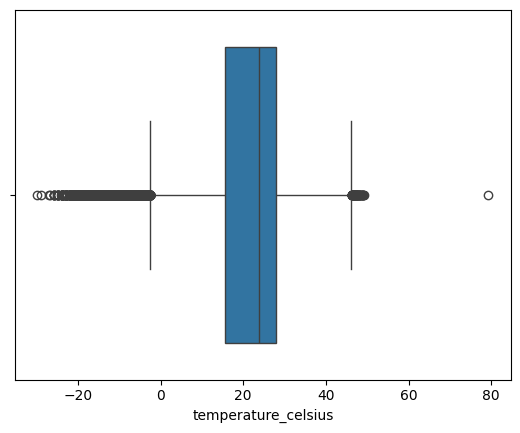

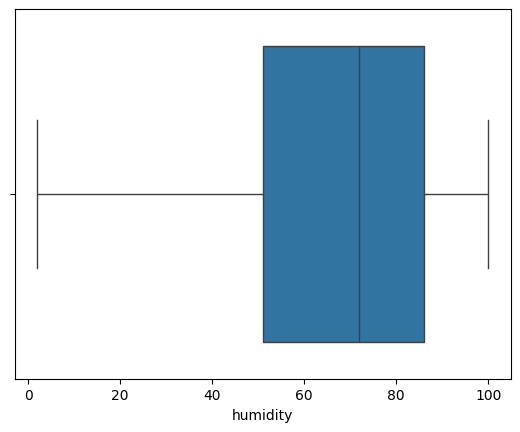

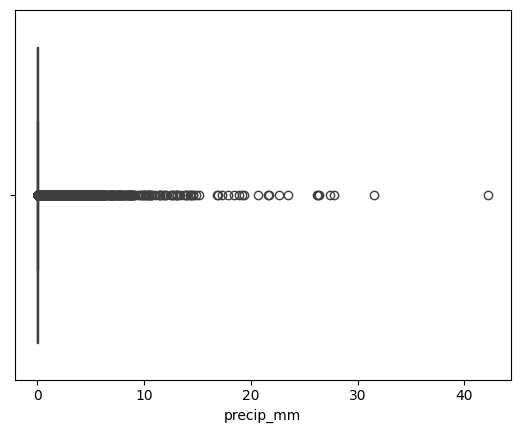

In [10]:
# Boxplots to identify potential outliers
sns.boxplot(x=df['temperature_celsius'])
plt.show()

sns.boxplot(x=df['humidity'])
plt.show()

sns.boxplot(x=df['precip_mm'])
plt.show()

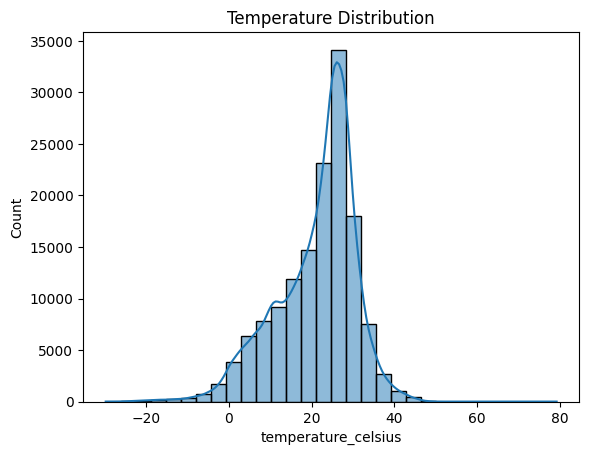

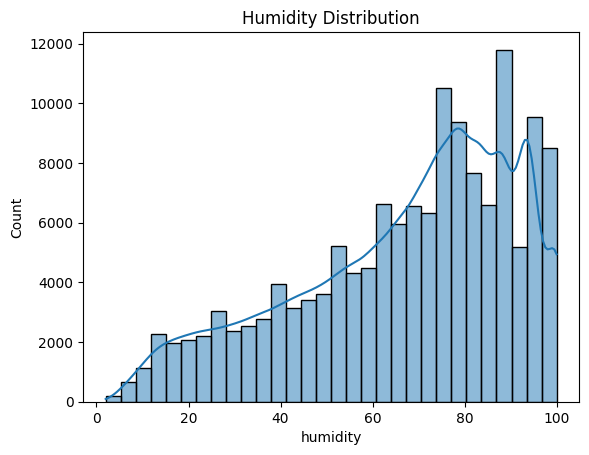

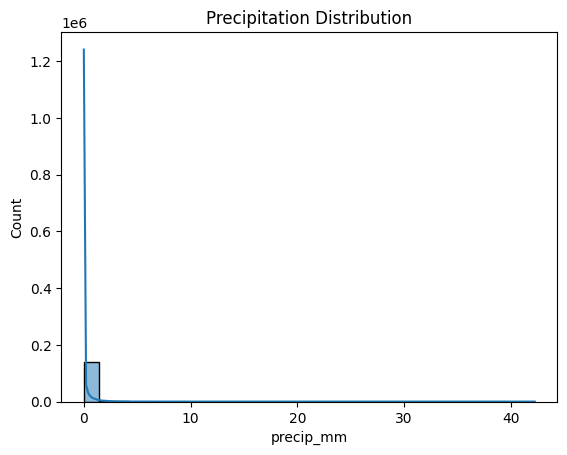

In [11]:
# Temperature distribution
sns.histplot(df['temperature_celsius'], bins=30, kde=True)
plt.title("Temperature Distribution")
plt.show()

# Humidity distribution
sns.histplot(df['humidity'], bins=30, kde=True)
plt.title("Humidity Distribution")
plt.show()

# Precipitation distribution
sns.histplot(df['precip_mm'], bins=30, kde=True)
plt.title("Precipitation Distribution")
plt.show()

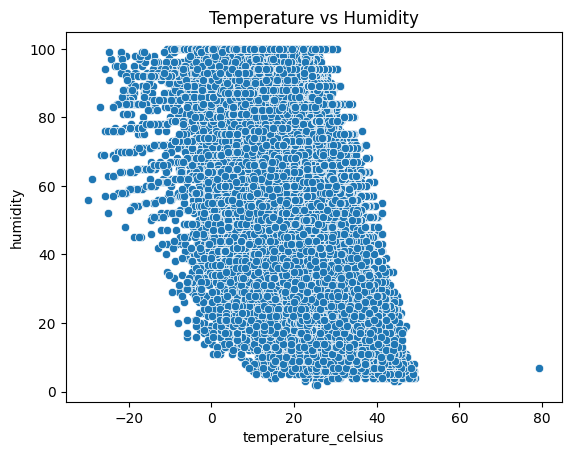

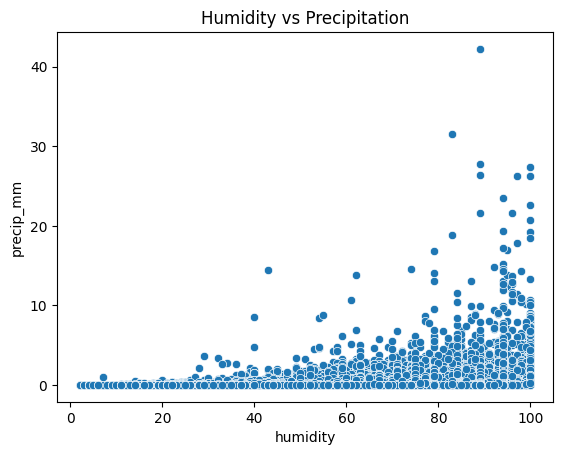

In [12]:
# Temperature vs Humidity relationship
sns.scatterplot(x='temperature_celsius', y='humidity', data=df)
plt.title("Temperature vs Humidity")
plt.show()

# Humidity vs Precipitation relationship
sns.scatterplot(x='humidity', y='precip_mm', data=df)
plt.title("Humidity vs Precipitation")
plt.show()

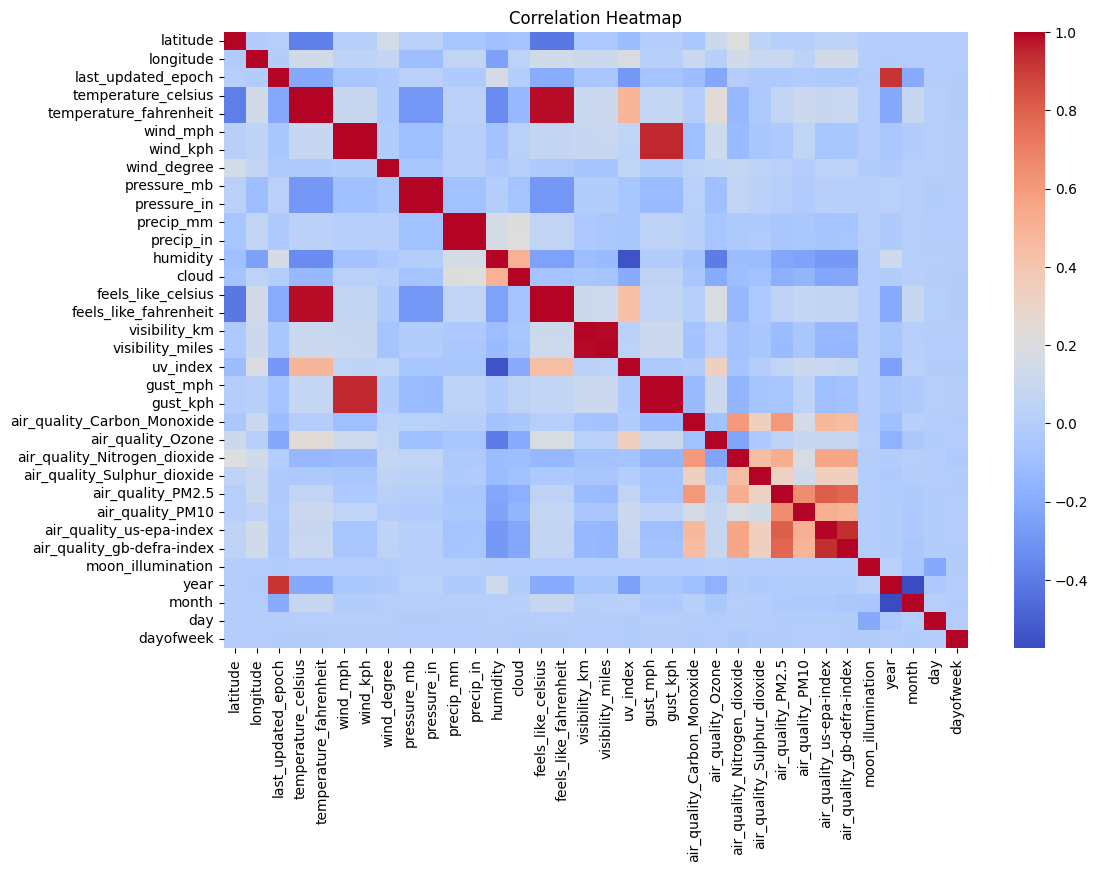

In [13]:
# Correlation heatmap for numerical features
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig(
    "correlation_heatmap.png",
    bbox_inches='tight'
)
plt.show()

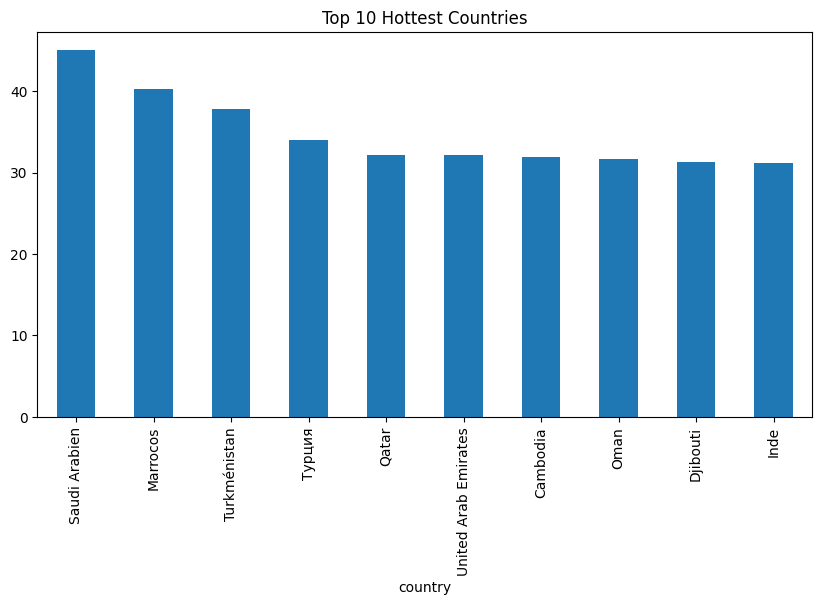

In [14]:
# Top 10 hottest countries
top_countries = (
    df.groupby('country')['temperature_celsius']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_countries.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Hottest Countries")
plt.show()

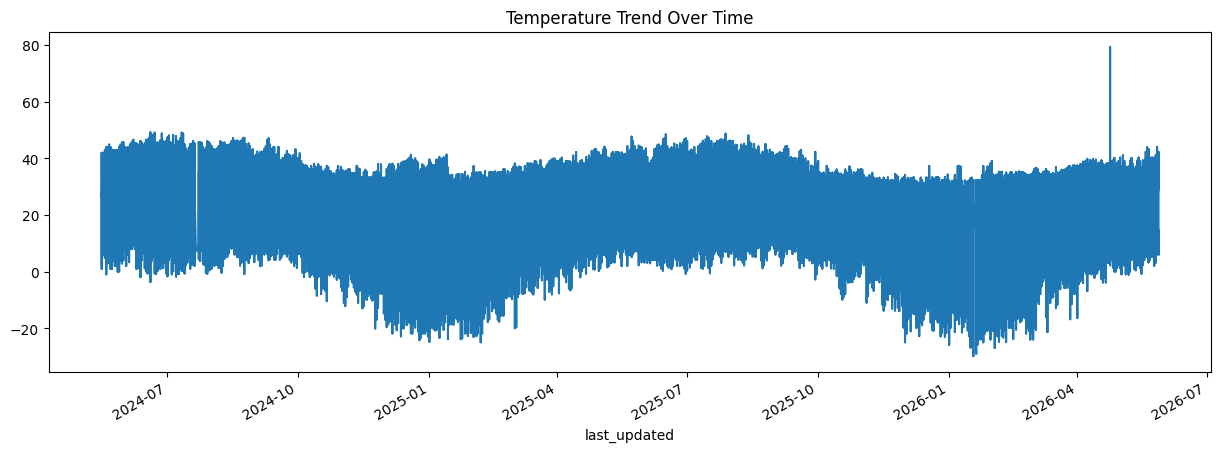

In [15]:
# Temperature trend over time
df['temperature_celsius'].plot(figsize=(15,5))
plt.title("Temperature Trend Over Time")
plt.show()

In [16]:
# Selected features for modeling
features = [
    'humidity',
    'pressure_mb',
    'precip_mm',
    'wind_kph',
    'cloud',
    'visibility_km',
    'uv_index',
    'gust_kph',
    'latitude',
    'longitude',
    'month',
    'day',
    'dayofweek'
]

X = df[features]
y = df['temperature_celsius']

In [17]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
# Train simple baseline model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
lr_pred = lr.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", root_mean_squared_error(y_test, lr_pred))
print("R2:", r2_score(y_test, lr_pred))

MAE: 5.6080329357951415
RMSE: 7.0044617954075665
R2: 0.4763015589809282


In [19]:
# Train advanced model for non-linear relationships
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
rf_pred = rf.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", root_mean_squared_error(y_test, rf_pred))
print("R2:", r2_score(y_test, rf_pred))

MAE: 1.302582075045993
RMSE: 1.897583898225206
R2: 0.9615643958037657


In [20]:
# Check for overfitting

train_r2 = rf.score(X_train, y_train)
test_r2 = rf.score(X_test, y_test)

print("Train R²:", train_r2)
print("Test R²:", test_r2)

Train R²: 0.9943920764189365
Test R²: 0.9615643958037657


In [21]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    'RMSE': [
        root_mean_squared_error(y_test, lr_pred),
        root_mean_squared_error(y_test, rf_pred)
    ],
    'R2': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred)
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,5.608033,7.004462,0.476302
1,Random Forest,1.302582,1.897584,0.961564


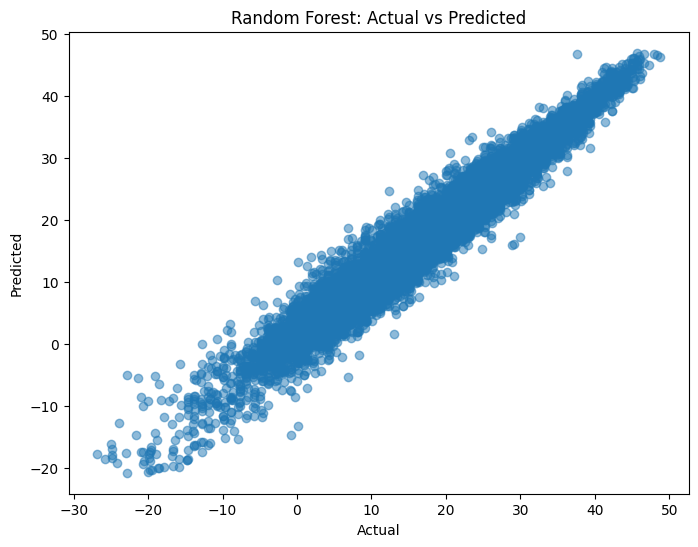

In [22]:
# Visual evaluation of model performance
plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest: Actual vs Predicted")
plt.savefig(
    "actual_vs_predicted.png",
    bbox_inches='tight'
)
plt.show()

In [23]:
# Validate model stability across dataset splits
scores = cross_val_score(rf, X, y, cv=5, scoring='r2')

print(scores)
print("Average R2:", scores.mean())

[0.79773929 0.87788771 0.84131037 0.90043043 0.86359182]
Average R2: 0.8561919251576471


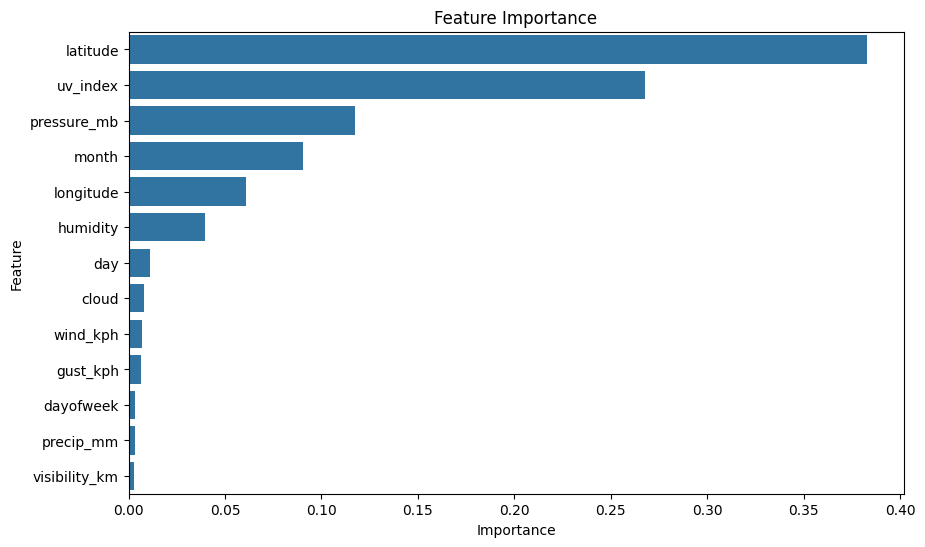

In [24]:
# Identify most influential features
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importance, x='Importance', y='Feature')
plt.title("Feature Importance")
plt.savefig(
    "feature_importance.png",
    bbox_inches='tight'
)

plt.show()

In [25]:
# Detect unusual weather patterns
anomaly_features = [
    'temperature_celsius',
    'humidity',
    'pressure_mb',
    'precip_mm',
    'wind_kph',
    'cloud',
    'visibility_km',
    'uv_index',
    'gust_kph',
    'latitude',
    'longitude',
    'month'
]

iso = IsolationForest(contamination=0.01, random_state=42)

df['anomaly'] = iso.fit_predict(df[anomaly_features])

df['anomaly'].value_counts()

anomaly
 1    142601
-1      1441
Name: count, dtype: int64

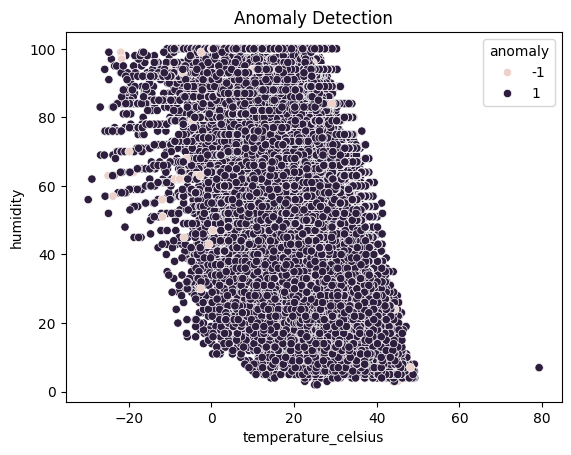

In [26]:
# Visualize anomalies
sns.scatterplot(
    x='temperature_celsius',
    y='humidity',
    hue='anomaly',
    data=df
)
plt.title("Anomaly Detection")
plt.savefig(
    "anomaly_detection.png",
    bbox_inches='tight'
)
plt.show()

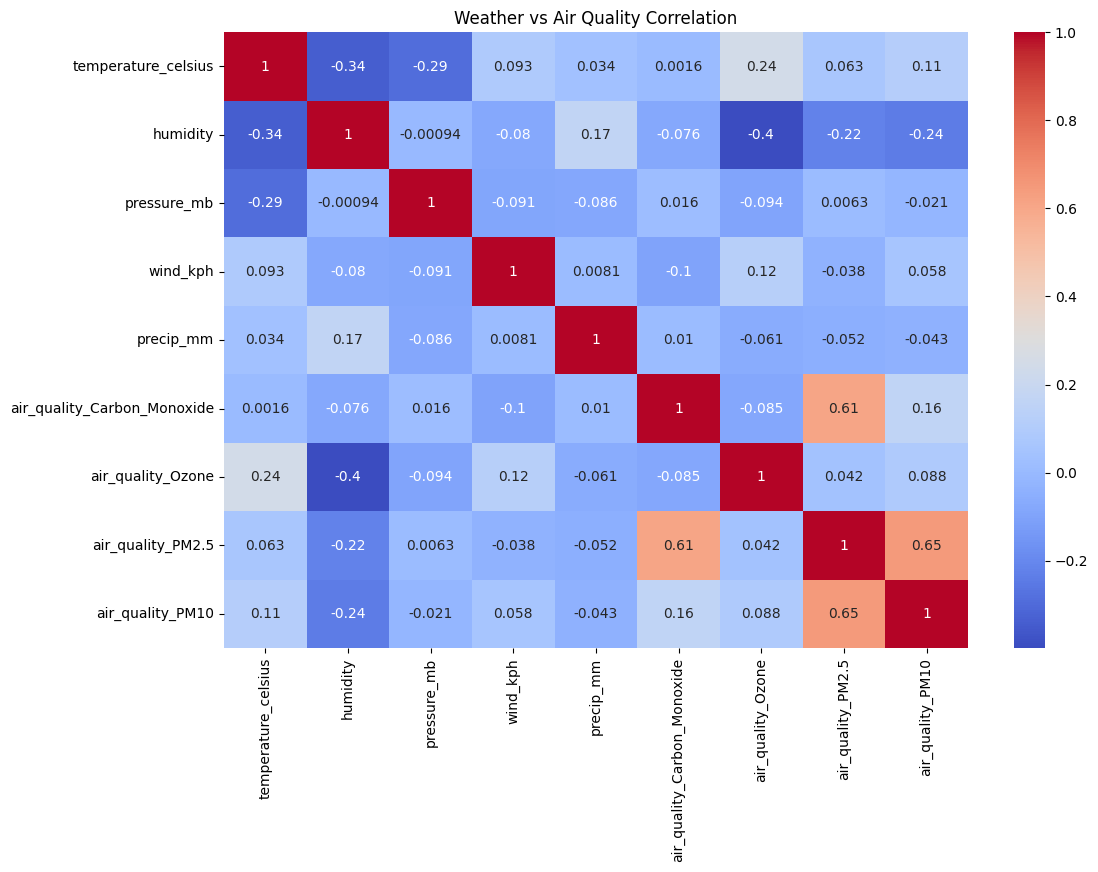

In [27]:
# Analyze relationship between weather and air quality
air_weather = [
    'temperature_celsius',
    'humidity',
    'pressure_mb',
    'wind_kph',
    'precip_mm',
    'air_quality_Carbon_Monoxide',
    'air_quality_Ozone',
    'air_quality_PM2.5',
    'air_quality_PM10'
]

corr = df[air_weather].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Weather vs Air Quality Correlation")
plt.savefig(
    "correlation_heatmap.png",
    bbox_inches='tight'
)
plt.show()

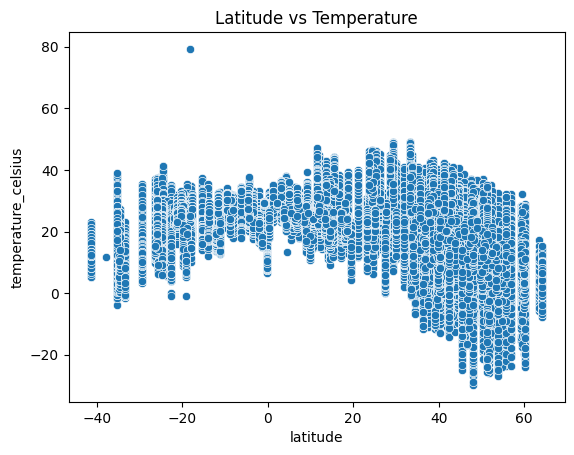

In [28]:
# Relationship between location and temperature
sns.scatterplot(
    x='latitude',
    y='temperature_celsius',
    data=df
)

plt.title("Latitude vs Temperature")
plt.savefig(
    "latitude_vs_temperature.png",
    bbox_inches='tight'
)
plt.show()

CONCLUSION

Key Findings

Random Forest outperformed Linear Regression.

Random Forest achieved:
      R² = 0.96
      MAE = 1.3
      RMSE = 1.8

Latitude was the most influential predictor of temperature.

Feature engineering significantly improved model performance.

Anomaly Detection identified unusual weather observations.

Environmental analysis revealed relationships between weather and air quality.

Spatial analysis showed geographical weather patterns across different regions.